<a href="https://colab.research.google.com/github/gfkaceli/RAPTOR_IMPROV/blob/main/HierarchicalRAG_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Link to the latex file: https://www.overleaf.com/project/67d58f3310ab2fd59286b347

* Link to GitHub: https://github.com/gfkaceli/RAPTOR_IMPROV

I detail what i have done so far. I primarily work off of the github but whenever i make a change there is automatically updates here, so we are good on that front. Right now I have the pipeline up and running and it does the comparisons. I have to implement some more of the indexing methods than I will test on the benchmarks and results will go here. The notebook just test on the sample data but the results don't really matter just that the experiments run. Once I finish the other two clustering methods, I will assess on the benchmark datasets and update this notebook accordingly. I left a section for you to leave any comments



# HIERARCHICAL RAG COMPARISON

This notebook builds a hierarchical tree with each clustering algorithm, answers a ground-truth
QA benchmark, and displays side-by-side comparison tables as styled pandas DataFrames.

**Clustering methods compared:**
| Method | Description | Reference |
|--------|-------------|----------|
| `original` | Upstream RAPTOR — GMM + UMAP (Sarthi et al., ICLR 2024) | [arXiv:2401.18059](https://arxiv.org/abs/2401.18059) |
| `gmm` | Same GMM algorithm through our new `BaseClusterer` interface | Parity check — should match `original` |
| `leiden` | Leiden community detection on a k-NN similarity graph | [Traag et al., Sci. Rep. 2019](https://doi.org/10.1038/s41598-019-41695-z) |

**Evaluation metrics:**
- **Token F1** — standard SQuAD token-overlap F1 (Gao et al. RAG survey, Table III)
- **BLEU-
- **Accuracy** — percentage of questions with EM = 1

> **Note:** For thesis results, I will use NarrativeQA / QASPER / QuALITY with published ground truth.

THIS IS ESSENTIALLY VERIFYING THE PIPELINE RUNS

GEORGES NOTES: TO DO-:

*   Implement KMeansClusterer, DBSCANClusterer, and AgglomerativeClusterer as BaseClusterer subclasses to generate different hierarchical trees for retrieval
*   Implement the SpaCy entity-edges callback (raptor/clustering/entity_edges.py) to enable the multi-feature graph variant of LeidenClusterer
*   Add parent_id and layer fields to Node in tree_structures.py for structure-aware retrieval (Contribution 2 — expansion/contraction ops)
*   Patch cluster_tree_builder.py to pass layer=layer to perform_clustering so layer-adaptive resolution actually activates
*   Implement ExtractiveMMRSummarizer and CentroidOnlySummarizer for the summarization ablation (Contribution 3)
*   Build the evaluation harness for NarrativeQA, QASPER, and QuALITY with published ground truth — the Cinderella and AI history benchmarks are smoke tests only
*   Add bootstrap confidence intervals to the eval output for statistical significance on the real datasets
*   Run eval_demo.py with --model-tier local-large or api to get meaningful QA scores — base tier FLAN-T5 is too weak to differentiate clustering methods
*   Write a proper README.md for the repo





DR LU'S NOTES:

ANYTHING YOU WANT TO ADD CAN GO HERE

In [1]:
!git clone https://github.com/gfkaceli/RAPTOR_IMPROV

Cloning into 'RAPTOR_IMPROV'...
remote: Enumerating objects: 210, done.
remote: Counting objects: 100% (210/210), done.
remote: Compressing objects: 100% (160/160), done.
remote: Total 210 (delta 104), reused 139 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (210/210), 566.16 KiB | 2.46 MiB/s, done.
Resolving deltas: 100% (104/104), done.


In [2]:
!git pull # pull updated

fatal: not a git repository (or any of the parent directories): .git


In [3]:
%cd RAPTOR_IMPROV/

/content/RAPTOR_IMPROV


In [4]:
!grep -Ev '^(pandas|torch)' requirements.txt > requirements-temp.txt
!cat requirements-temp.txt
!pip install -r requirements-temp.txt

openai == 2.26.0
sentence_transformers == 5.2.3
tenacity == 9.1.4
scikit-learn == 1.8.0
faiss-cpu == 1.13.1
tiktoken == 0.12.0
umap-learn == 0.5.11
igraph == 1.0.0
leidenalg == 0.11.0
python-igraph == 1.0.0
texttable == 1.7.0
datasets == 4.8.5
accelerate == 1.13.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 190.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 166.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.9/90.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 222.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━

## 1. Setup & Imports

In [5]:
import os
import string
import time
import warnings
from collections import Counter
from typing import Dict, List, Tuple

import pandas as pd
import numpy as np

# Suppress noisy transformer warnings in notebook output
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# RAPTOR reads OPENAI_API_KEY at import time even when using local models.
# Set a dummy value so the import doesn't crash.
os.environ.setdefault("OPENAI_API_KEY", "not-used-in-local-demo")


# Upstream RAPTOR imports
from raptor import (
    BaseSummarizationModel,
    BaseQAModel,
    RetrievalAugmentationConfig,
    RetrievalAugmentation,
)
from raptor.cluster_tree_builder import ClusterTreeConfig
from raptor.cluster_utils import RAPTOR_Clustering
from raptor.EmbeddingModels import SBertEmbeddingModel

# NEW: our clustering subpackage
from raptor.clustering import GMMClusterer, LeidenClusterer, LeidenConfig, KMeansClusterer

print("All imports successful.")

All imports successful.


## 2. Evaluation Metrics

We use two metrics, both standard in RAG QA evaluation:

- **Token F1**: tokenize both the prediction and the ground truth, count overlapping tokens,
  compute precision / recall / F1. This is the same metric used by SQuAD (Rajpurkar et al., 2016)
  and reported by Sarthi et al. for QASPER.
  
- **Keyword EM**: a lenient exact-match variant. Instead of requiring the full ground-truth string
  as a substring, we check whether a set of critical keywords all appear in the answer. This is
  necessary because FLAN-T5 paraphrases freely — "Her fairy godmother helped" is a correct answer
  even though it doesn't match "The fairy godmother appeared" as a substring.

In [6]:
def normalize_text(text: str) -> str:
    """Lowercase, strip punctuation and extra whitespace. Matches SQuAD eval."""
    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = " ".join(text.split())
    return text


def token_f1(prediction: str, ground_truth: str) -> Tuple[float, float, float]:
    """
    Token-level precision, recall, F1.

    Returns (precision, recall, f1).
    """
    pred_tokens = normalize_text(prediction).split()
    gt_tokens = normalize_text(ground_truth).split()

    if not pred_tokens and not gt_tokens:
        return 1.0, 1.0, 1.0
    if not pred_tokens or not gt_tokens:
        return 0.0, 0.0, 0.0

    common = Counter(pred_tokens) & Counter(gt_tokens)
    num_common = sum(common.values())

    if num_common == 0:
        return 0.0, 0.0, 0.0

    precision = num_common / len(pred_tokens)
    recall = num_common / len(gt_tokens)
    f1 = 2 * precision * recall / (precision + recall)
    return precision, recall, f1


def keyword_match(prediction: str, keywords: List[str]) -> bool:
    """True if ALL keywords appear in the prediction (case-insensitive)."""
    pred_lower = normalize_text(prediction)
    return all(kw.lower() in pred_lower for kw in keywords)


# ---- Quick sanity check ----
p, r, f = token_f1("The prince married Cinderella",
                    "The prince found Cinderella and married her")
print(f"Sanity check — P={p:.3f}  R={r:.3f}  F1={f:.3f}  (expect F1 > 0.5)")
assert f > 0.5, "Token F1 sanity check failed"
print("Metrics OK.")

Sanity check — P=1.000  R=0.571  F1=0.727  (expect F1 > 0.5)
Metrics OK.


## 3. Ground-Truth QA Benchmark

10 question–answer pairs over the Cinderella passage. Each entry includes:
- The question
- A reference answer (for token-F1)
- A keyword list (for lenient EM)

> These are hand-written reference answers, adequate for a pipeline smoke test
> but NOT for a thesis evaluation. Use NarrativeQA / QASPER / QuALITY for that.

In [7]:
BENCHMARK = [
    {"question": "How did Cinderella reach her happy ending?",
     "ground_truth": "The prince found Cinderella by fitting the glass slipper on her foot, recognized her, and they married.",
     "keywords": ["prince", "slipper", "married"]},

    {"question": "Who helped Cinderella attend the ball?",
     "ground_truth": "Her fairy godmother appeared and transformed a pumpkin into a coach and her worn clothes into a beautiful gown.",
     "keywords": ["fairy", "godmother"]},

    {"question": "What did Cinderella leave behind at the ball?",
     "ground_truth": "Cinderella left behind one glass slipper when she fled before midnight.",
     "keywords": ["glass", "slipper"]},

    {"question": "Why did Cinderella have to leave the ball before midnight?",
     "ground_truth": "The magic from the fairy godmother would end at midnight.",
     "keywords": ["magic", "midnight"]},

    {"question": "How did the prince find Cinderella after the ball?",
     "ground_truth": "The prince searched the kingdom for the woman whose foot fit the glass slipper.",
     "keywords": ["searched", "slipper", "fit"]},

    {"question": "What does the fairy godmother symbolize in the story?",
     "ground_truth": "The fairy godmother symbolizes hope.",
     "keywords": ["hope"]},

    {"question": "What is the glass slipper's role in the story?",
     "ground_truth": "The lost slipper is the key piece of evidence that allows the prince to identify Cinderella.",
     "keywords": ["evidence", "identify"]},

    {"question": "Who forced Cinderella to work day and night?",
     "ground_truth": "Her cruel stepmother and two jealous stepsisters forced her to work.",
     "keywords": ["stepmother", "stepsisters"]},

    {"question": "What themes does the Cinderella story illustrate?",
     "ground_truth": "The story illustrates transformation, perseverance, and recognition.",
     "keywords": ["transformation", "perseverance"]},

    {"question": "What was the pumpkin transformed into?",
     "ground_truth": "The fairy godmother transformed a pumpkin into a coach.",
     "keywords": ["coach"]},
]

# Preview as a DataFrame
benchmark_df = pd.DataFrame(BENCHMARK)
benchmark_df["keywords"] = benchmark_df["keywords"].apply(lambda x: ", ".join(x))
benchmark_df.index = range(1, len(benchmark_df) + 1)
benchmark_df.index.name = "Q#"
benchmark_df

,question,ground_truth,keywords
Q#,,,
1,How did Cinderella reach her happy ending?,The prince found Cinderella by fitting the gla...,"prince, slipper, married"
2,Who helped Cinderella attend the ball?,Her fairy godmother appeared and transformed a...,"fairy, godmother"
3,What did Cinderella leave behind at the ball?,Cinderella left behind one glass slipper when ...,"glass, slipper"
4,Why did Cinderella have to leave the ball befo...,The magic from the fairy godmother would end a...,"magic, midnight"
5,How did the prince find Cinderella after the b...,The prince searched the kingdom for the woman ...,"searched, slipper, fit"
6,What does the fairy godmother symbolize in the...,The fairy godmother symbolizes hope.,hope
7,What is the glass slipper's role in the story?,The lost slipper is the key piece of evidence ...,"evidence, identify"
8,Who forced Cinderella to work day and night?,Her cruel stepmother and two jealous stepsiste...,"stepmother, stepsisters"
9,What themes does the Cinderella story illustrate?,"The story illustrates transformation, persever...","transformation, perseverance"


## 4. Document & Model Setup

The Cinderella passage and the three model wrappers (SBERT embeddings, DistilBART
summarization, FLAN-T5 QA) are shared across all clustering methods. Loading them
once avoids redundant GPU/CPU work.

In [8]:
DEMO_TEXT = (
    "Cinderella lived with her cruel stepmother and two jealous stepsisters, who forced "
    "her to work day and night. When the royal ball was announced, Cinderella wished to go "
    "but was forbidden. Her fairy godmother appeared and transformed a pumpkin into a coach, "
    "mice into horses, and Cinderella's worn clothes into a beautiful gown with glass slippers. "
    "She attended the ball and danced with the prince, but she had to leave before midnight, "
    "when the magic would end. As she fled, one glass slipper was left behind. The prince "
    "searched the kingdom for the woman whose foot fit the slipper. When he came to "
    "Cinderella's house, the slipper fit her perfectly, and he recognized her as the one "
    "he loved. Cinderella married the prince and finally found her happy ending.\n\n"
    "The story is often used to illustrate transformation, perseverance, and recognition. "
    "In many retellings, the fairy godmother symbolizes hope, while the lost slipper becomes "
    "the key piece of evidence that allows the prince to identify Cinderella."
)

print(f"Document length: {len(DEMO_TEXT)} chars, ~{len(DEMO_TEXT.split())} words")

Document length: 1006 chars, ~165 words


In [9]:
# ---------------------------------------------------------------------------
# Local model wrappers
# In transformers v5.8+ the text-generation pipeline does NOT support
# encoder-decoder models (T5, BART). So we use model.generate() directly
# for those, and the pipeline only for causal models (Mistral, Llama).
# ---------------------------------------------------------------------------

class LocalBartSummarizationModel(BaseSummarizationModel):
    def __init__(self, model_name="sshleifer/distilbart-cnn-12-6"):
        self.model_name = model_name
        self._model = None
        self._tokenizer = None
        self._pipeline = None
        self._load_error = None
        self._is_causal = None
    def _ensure_loaded(self):
        if self._model is not None or self._pipeline is not None or self._load_error is not None:
            return
        try:
            from transformers import AutoConfig, AutoTokenizer
            config = AutoConfig.from_pretrained(self.model_name, trust_remote_code=True)
            self._is_causal = not (hasattr(config, "is_encoder_decoder") and config.is_encoder_decoder)
            if self._is_causal:
                from transformers import pipeline as hf_pipeline
                self._pipeline = hf_pipeline("text-generation", model=self.model_name, tokenizer=self.model_name, trust_remote_code=True, device_map="auto")
            else:
                from transformers import AutoModelForSeq2SeqLM
                self._tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
                self._model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name, trust_remote_code=True)
        except Exception as exc:
            self._load_error = exc
            print(f"  [WARN] Summarizer load failed: {exc}")
    def summarize(self, context, max_tokens=150):
        text = " ".join(str(context).split())
        if not text: return ""
        self._ensure_loaded()
        max_out = min(int(max_tokens), 128)
        if self._model is not None and not self._is_causal:
            try:
                inputs = self._tokenizer(f"Summarize: {text}", return_tensors="pt", truncation=True, max_length=1024)
                outputs = self._model.generate(**inputs, max_new_tokens=max_out, do_sample=False)
                return self._tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            except Exception: pass
        if self._pipeline is not None and self._is_causal:
            prompt = f"Summarize the following text concisely:\n\n{text}\n\nSummary:"
            try:
                result = self._pipeline(prompt, max_new_tokens=max_out, do_sample=False)
                generated = result[0]["generated_text"]
                return generated.split("Summary:")[-1].strip() if "Summary:" in generated else generated[len(prompt):].strip()
            except Exception: pass
        sentences = [s.strip() for s in text.replace("\n", " ").split(".") if s.strip()]
        return ". ".join(sentences[:2]) + ("." if sentences else "")


class LocalFlanQAModel(BaseQAModel):
    def __init__(self, model_name="google/flan-t5-base"):
        self.model_name = model_name
        self._model = None
        self._tokenizer = None
        self._pipeline = None
        self._load_error = None
        self._is_causal = None
    def _ensure_loaded(self):
        if self._model is not None or self._pipeline is not None or self._load_error is not None:
            return
        try:
            from transformers import AutoConfig, AutoTokenizer
            config = AutoConfig.from_pretrained(self.model_name, trust_remote_code=True)
            self._is_causal = not (hasattr(config, "is_encoder_decoder") and config.is_encoder_decoder)
            if self._is_causal:
                from transformers import pipeline as hf_pipeline
                self._pipeline = hf_pipeline("text-generation", model=self.model_name, tokenizer=self.model_name, trust_remote_code=True, device_map="auto")
            else:
                from transformers import AutoModelForSeq2SeqLM
                self._tokenizer = AutoTokenizer.from_pretrained(self.model_name, trust_remote_code=True)
                self._model = AutoModelForSeq2SeqLM.from_pretrained(self.model_name, trust_remote_code=True)
        except Exception as exc:
            self._load_error = exc
            print(f"  [WARN] QA model load failed: {exc}")
    def answer_question(self, context, question):
        context = " ".join(str(context).split())
        question = str(question).strip()
        if not context: return "No context available."
        self._ensure_loaded()
        prompt = f"Based on the following context, answer the question in one or two sentences. Be specific and include key names, dates, and facts from the context.\n\nContext: {context}\n\nQuestion: {question}\n\nAnswer:"
        if self._model is not None and not self._is_causal:
            try:
                inputs = self._tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1024)
                outputs = self._model.generate(**inputs, max_new_tokens=64, do_sample=False)
                return self._tokenizer.decode(outputs[0], skip_special_tokens=True).strip()
            except Exception: pass
        if self._pipeline is not None and self._is_causal:
            try:
                result = self._pipeline(prompt, max_new_tokens=64, do_sample=False)
                generated = result[0]["generated_text"]
                return generated.split("Answer:")[-1].strip() if "Answer:" in generated else generated[len(prompt):].strip()
            except Exception: pass
        sentences = [s.strip() for s in context.split(".") if s.strip()]
        keywords = [t.lower() for t in question.split() if len(t) > 3]
        best, best_score = "", -1
        for s in sentences:
            score = sum(k in s.lower() for k in keywords)
            if score > best_score: best, best_score = s, score
        return best + "." if best else "No answer found."


In [10]:
# Load models once — shared across all methods
print("Loading models...")
emb_model = SBertEmbeddingModel(model_name="sentence-transformers/all-MiniLM-L6-v2")
summ_model = LocalBartSummarizationModel()
qa_model = LocalFlanQAModel()
print("Models ready.")

Loading models...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models ready.


## 5. Config Factories

Each function builds a `RetrievalAugmentationConfig` that differs ONLY in the
clustering algorithm. Everything else — embedding model, summarizer, QA model,
number of tree layers, top-k retrieval — is identical. This is the controlled
comparison design: one independent variable (clustering), everything else held constant.

In [11]:
def make_original_config():
    """
    Upstream RAPTOR — uses RAPTOR_Clustering (GMM + UMAP) internally.
    This is the control condition.
    """
    return RetrievalAugmentationConfig(
        embedding_model=emb_model,
        summarization_model=summ_model,
        qa_model=qa_model,
        tb_max_tokens=80,
        tb_num_layers=3,
        tb_summarization_length=80,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )


def make_gmm_config():
    """
    GMM through our new BaseClusterer interface.
    Should produce near-identical results to `original`.
    Any divergence means either: (a) the UMAP seed fix changed the tree,
    or (b) there's a wrapper bug.
    """
    clusterer = GMMClusterer(
        reduction_dimension=10,
        soft_threshold=0.1,
        force_hard_clustering=False,
        random_state=224,
        max_length_in_cluster=3500,
    )
    tree_config = ClusterTreeConfig(
        clustering_algorithm=clusterer,
        clustering_params={},
        reduction_dimension=10,
        summarization_model=summ_model,
        embedding_models={"EMB": emb_model},
        cluster_embedding_model="EMB",
        max_tokens=80,
        num_layers=3,
        summarization_length=80,
    )
    return RetrievalAugmentationConfig(
        tree_builder_config=tree_config,
        qa_model=qa_model,
        embedding_model=emb_model,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )


def make_leiden_config():
    """
    Leiden community detection on a k-NN similarity graph.
    Layer-adaptive resolution: tighter at layer 0 (many small clusters),
    looser at layer 1 (fewer broad clusters).
    """
    leiden_cfg = LeidenConfig(
        k_neighbors=10,
        use_adjacency_edges=True,
        adjacency_weight=0.5,
        resolution=1.0,
        resolution_schedule={0: 1.2, 1: 0.8},
        partition_type="RBConfiguration",
        min_cluster_size=1,
    )
    clusterer = LeidenClusterer(
        config=leiden_cfg,
        random_state=224,
        max_length_in_cluster=3500,
    )
    tree_config = ClusterTreeConfig(
        clustering_algorithm=clusterer,
        clustering_params={},
        reduction_dimension=10,
        summarization_model=summ_model,
        embedding_models={"EMB": emb_model},
        cluster_embedding_model="EMB",
        max_tokens=80,
        num_layers=3,
        summarization_length=80,
    )
    return RetrievalAugmentationConfig(
        tree_builder_config=tree_config,
        qa_model=qa_model,
        embedding_model=emb_model,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )

def make_kmeans_config():
    clusterer = KMeansClusterer(
        k_strategy="silhouette",
        max_k=10,
        random_state=224,
        max_length_in_cluster=3500,
    )
    tree_config = ClusterTreeConfig(
        clustering_algorithm=clusterer,
        clustering_params={},
        reduction_dimension=10,
        summarization_model=summ_model,
        embedding_models={"EMB": emb_model},
        cluster_embedding_model="EMB",
        max_tokens=80,
        num_layers=3,
        summarization_length=80,
    )
    return RetrievalAugmentationConfig(
        tree_builder_config=tree_config,
        qa_model=qa_model,
        embedding_model=emb_model,
        tr_top_k=5,
        tr_selection_mode="top_k",
    )



# Registry of all methods to evaluate
METHODS = {
    "original": {"factory": make_original_config, "desc": "RAPTOR (GMM+UMAP) upstream"},
    "gmm":      {"factory": make_gmm_config,      "desc": "GMMClusterer (new interface)"},
    "leiden":   {"factory": make_leiden_config,     "desc": "LeidenClusterer (k-NN graph)"},
    "kmeans":   {"factory": make_kmeans_config, "desc": "KMeansClusterer (silhouette K)"},
}

print(f"Registered {len(METHODS)} methods: {', '.join(METHODS.keys())}")

Registered 4 methods: original, gmm, leiden, kmeans


## 6. Run the Evaluation Loop

For each clustering method:
1. Build the RAPTOR tree (timed)
2. Record tree statistics (layers, nodes, depth)
3. Answer every benchmark question
4. Score each answer with Token F1 and Keyword EM

All results are collected into a list of dictionaries, then converted to DataFrames.

In [12]:
# Accumulators
summary_rows = []      # one row per method
detail_rows = []       # one row per (method, question)
tree_stats_rows = []   # one row per (method, layer)

for method_name, method_info in METHODS.items():
    print(f"\n{'='*60}")
    print(f"  {method_name} — {method_info['desc']}")
    print(f"{'='*60}")

    # --- Build config (skip method if deps are missing) ---
    try:
        config = method_info["factory"]()
    except ImportError as exc:
        print(f"  SKIPPED: {exc}")
        continue

    # --- Build tree ---
    ra = RetrievalAugmentation(config=config)
    t0 = time.time()
    ra.add_documents(DEMO_TEXT)
    build_time = time.time() - t0

    tree = ra.tree
    total_nodes = len(tree.all_nodes)
    leaf_nodes = len(tree.leaf_nodes)
    summary_nodes = total_nodes - leaf_nodes
    num_layers = tree.num_layers

    print(f"  Tree: {num_layers} layers, {total_nodes} nodes "
          f"({leaf_nodes} leaves + {summary_nodes} summaries) in {build_time:.2f}s")

    # Per-layer breakdown
    for layer_idx, nodes in sorted(tree.layer_to_nodes.items()):
        tree_stats_rows.append({
            "method": method_name,
            "layer": layer_idx,
            "node_count": len(nodes),
        })
        print(f"    Layer {layer_idx}: {len(nodes)} nodes")

    # --- Answer questions ---
    total_em = 0
    total_f1 = 0.0
    total_prec = 0.0
    total_rec = 0.0

    for i, qa in enumerate(BENCHMARK):
        t_q = time.time()
        answer = ra.answer_question(question=qa["question"])
        answer_time = time.time() - t_q

        prec, rec, f1 = token_f1(answer, qa["ground_truth"])
        em = 1 if keyword_match(answer, qa["keywords"]) else 0

        total_em += em
        total_f1 += f1
        total_prec += prec
        total_rec += rec

        detail_rows.append({
            "method": method_name,
            "q_num": i + 1,
            "question": qa["question"],
            "ground_truth": qa["ground_truth"],
            "predicted": answer,
            "keywords": ", ".join(qa["keywords"]),
            "em": em,
            "precision": round(prec, 4),
            "recall": round(rec, 4),
            "f1": round(f1, 4),
            "answer_time_sec": round(answer_time, 3),
        })

        status = "PASS" if em else "FAIL"
        print(f"    Q{i+1} [{status}] F1={f1:.3f}  {qa['question'][:50]}")

    n = len(BENCHMARK)
    summary_rows.append({
        "method": method_name,
        "description": method_info["desc"],
        "accuracy_%": round(total_em / n * 100, 1),
        "mean_f1": round(total_f1 / n, 4),
        "mean_precision": round(total_prec / n, 4),
        "mean_recall": round(total_rec / n, 4),
        "num_layers": num_layers,
        "total_nodes": total_nodes,
        "leaf_nodes": leaf_nodes,
        "summary_nodes": summary_nodes,
        "build_time_sec": round(build_time, 2),
    })

print("\n" + "="*60)
print("  All methods complete.")
print("="*60)


  original — RAPTOR (GMM+UMAP) upstream
  Tree: 0 layers, 3 nodes (3 leaves + 0 summaries) in 0.56s
    Layer 0: 3 nodes


config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

    Q1 [FAIL] F1=0.381  How did Cinderella reach her happy ending?
    Q2 [PASS] F1=0.190  Who helped Cinderella attend the ball?
    Q3 [PASS] F1=0.308  What did Cinderella leave behind at the ball?
    Q4 [FAIL] F1=0.571  Why did Cinderella have to leave the ball before m
    Q5 [PASS] F1=0.963  How did the prince find Cinderella after the ball?
    Q6 [PASS] F1=0.333  What does the fairy godmother symbolize in the sto
    Q7 [PASS] F1=0.938  What is the glass slipper's role in the story?
    Q8 [PASS] F1=0.778  Who forced Cinderella to work day and night?
    Q9 [PASS] F1=0.727  What themes does the Cinderella story illustrate?
    Q10 [PASS] F1=0.250  What was the pumpkin transformed into?

  gmm — GMMClusterer (new interface)
  Tree: 0 layers, 3 nodes (3 leaves + 0 summaries) in 0.01s
    Layer 0: 3 nodes
    Q1 [FAIL] F1=0.381  How did Cinderella reach her happy ending?
    Q2 [PASS] F1=0.190  Who helped Cinderella attend the ball?
    Q3 [PASS] F1=0.308  What did Cinderella leav

## 7. Results: Summary Table

One row per clustering method. The best value in each metric column is highlighted.

**What to look for:**
- `original` vs `gmm` should be near-identical (parity check for the new interface)
- `leiden` differences reflect the actual clustering algorithm change
- `build_time_sec` shows computational cost of each clusterer

In [13]:
# Build the summary DataFrame
df_summary = pd.DataFrame(summary_rows)

if len(df_summary) > 0:
    df_summary = df_summary.set_index("method")

    # Highlight the best value in each numeric column
    # (higher is better for accuracy/F1/precision/recall; lower is better for build time)
    higher_better = ["accuracy_%", "mean_f1", "mean_precision", "mean_recall"]
    lower_better = ["build_time_sec"]

    def highlight_best(col):
        """Bold-green the best value in the column."""
        styles = [""] * len(col)
        if col.name in higher_better:
            best_idx = col.idxmax()
        elif col.name in lower_better:
            best_idx = col.idxmin()
        else:
            return styles
        for i, idx in enumerate(col.index):
            if idx == best_idx:
                styles[i] = "background-color: #d4edda; font-weight: bold"
        return styles

    display(df_summary.style.apply(highlight_best).set_caption(
        "Clustering Method Comparison — Summary Metrics"
    ).format({
        "accuracy_%": "{:.1f}%",
        "mean_f1": "{:.4f}",
        "mean_precision": "{:.4f}",
        "mean_recall": "{:.4f}",
        "build_time_sec": "{:.2f}s",
    }))
else:
    print("No methods completed successfully.")

,description,accuracy_%,mean_f1,mean_precision,mean_recall,num_layers,total_nodes,leaf_nodes,summary_nodes,build_time_sec
method,,,,,,,,,,
original,RAPTOR (GMM+UMAP) upstream,80.0%,0.5439,0.9137,0.4530,0,3,3,0,0.56s
gmm,GMMClusterer (new interface),80.0%,0.5439,0.9137,0.4530,0,3,3,0,0.01s
leiden,LeidenClusterer (k-NN graph),80.0%,0.5439,0.9137,0.4530,0,3,3,0,0.01s
kmeans,KMeansClusterer (silhouette K),80.0%,0.5439,0.9137,0.4530,0,3,3,0,0.01s


## 8. Results: Per-Question Breakdown

Pivoted view: one row per question, one column group per method.
Shows exactly which questions each method gets right or wrong.

In [14]:
df_detail = pd.DataFrame(detail_rows)

if len(df_detail) > 0:
    # Pivot: rows = questions, columns = (method, metric)
    pivot_f1 = df_detail.pivot(index="q_num", columns="method", values="f1")
    pivot_em = df_detail.pivot(index="q_num", columns="method", values="em")

    # Combine into a single table with (method, F1) and (method, EM) columns
    pivot_f1.columns = [f"{m} F1" for m in pivot_f1.columns]
    pivot_em.columns = [f"{m} EM" for m in pivot_em.columns]

    # Interleave: for each method, show EM then F1 side by side
    methods_present = [m for m in METHODS if m in df_detail["method"].unique()]
    ordered_cols = []
    for m in methods_present:
        ordered_cols.append(f"{m} EM")
        ordered_cols.append(f"{m} F1")

    # Add the question text
    q_text = df_detail.drop_duplicates("q_num").set_index("q_num")["question"]
    pivot = pd.concat([q_text, pivot_em, pivot_f1], axis=1)[['question'] + ordered_cols]

    # Style: green background for EM=1, red for EM=0
    def color_em(val):
        if isinstance(val, (int, float)):
            if val == 1:
                return "background-color: #d4edda"
            elif val == 0:
                return "background-color: #f8d7da"
        return ""

    em_cols = [c for c in pivot.columns if c.endswith(" EM")]
    styled = pivot.style.map(color_em, subset=em_cols).format(
        {c: "{:.3f}" for c in pivot.columns if c.endswith(" F1")}
    ).set_caption("Per-Question Results (EM: green=pass, red=fail)")

    display(styled)
else:
    print("No detail results to display.")

,question,original EM,original F1,gmm EM,gmm F1,leiden EM,leiden F1,kmeans EM,kmeans F1
q_num,,,,,,,,,
1,How did Cinderella reach her happy ending?,0,0.381,0,0.381,0,0.381,0,0.381
2,Who helped Cinderella attend the ball?,1,0.191,1,0.191,1,0.191,1,0.191
3,What did Cinderella leave behind at the ball?,1,0.308,1,0.308,1,0.308,1,0.308
4,Why did Cinderella have to leave the ball before midnight?,0,0.571,0,0.571,0,0.571,0,0.571
5,How did the prince find Cinderella after the ball?,1,0.963,1,0.963,1,0.963,1,0.963
6,What does the fairy godmother symbolize in the story?,1,0.333,1,0.333,1,0.333,1,0.333
7,What is the glass slipper's role in the story?,1,0.938,1,0.938,1,0.938,1,0.938
8,Who forced Cinderella to work day and night?,1,0.778,1,0.778,1,0.778,1,0.778
9,What themes does the Cinderella story illustrate?,1,0.727,1,0.727,1,0.727,1,0.727


## 9. Results: Full Predicted Answers

For auditing: the complete predicted answer text for every (method, question) pair.
Useful for spotting cases where F1 is low but the answer is actually reasonable (or vice versa).

In [15]:
if len(df_detail) > 0:
    # Show predicted answers side by side
    answers_pivot = df_detail.pivot(
        index="q_num", columns="method", values="predicted"
    )
    answers_pivot.insert(0, "question",
        df_detail.drop_duplicates("q_num").set_index("q_num")["question"]
    )
    # Wrap long text for readability
    display(answers_pivot.style.set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left",
        "max-width": "300px",
    }).set_caption("Full Predicted Answers by Method"))

method,question,gmm,kmeans,leiden,original
q_num,,,,,
1,How did Cinderella reach her happy ending?,Cinderella married the prince,Cinderella married the prince,Cinderella married the prince,Cinderella married the prince
2,Who helped Cinderella attend the ball?,fairy godmother,fairy godmother,fairy godmother,fairy godmother
3,What did Cinderella leave behind at the ball?,glass slipper,glass slipper,glass slipper,glass slipper
4,Why did Cinderella have to leave the ball before midnight?,the magic would end,the magic would end,the magic would end,the magic would end
5,How did the prince find Cinderella after the ball?,The prince searched the kingdom for the woman whose foot fit the slipper,The prince searched the kingdom for the woman whose foot fit the slipper,The prince searched the kingdom for the woman whose foot fit the slipper,The prince searched the kingdom for the woman whose foot fit the slipper
6,What does the fairy godmother symbolize in the story?,hope,hope,hope,hope
7,What is the glass slipper's role in the story?,The lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella,The lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella,The lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella,The lost slipper becomes the key piece of evidence that allows the prince to identify Cinderella
8,Who forced Cinderella to work day and night?,her cruel stepmother and two jealous stepsisters,her cruel stepmother and two jealous stepsisters,her cruel stepmother and two jealous stepsisters,her cruel stepmother and two jealous stepsisters
9,What themes does the Cinderella story illustrate?,"transformation, perseverance, and recognition","transformation, perseverance, and recognition","transformation, perseverance, and recognition","transformation, perseverance, and recognition"


## 10. Tree Structure Comparison

How many nodes does each method produce at each tree layer?
This directly reflects the clustering granularity.

method,gmm,kmeans,leiden,original
Tree Layer,,,,
0,3,3,3,3
TOTAL,3,3,3,3


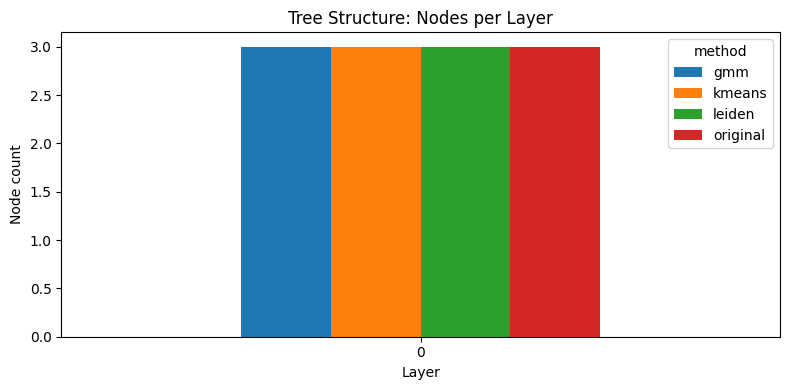

In [16]:
df_tree = pd.DataFrame(tree_stats_rows)

if len(df_tree) > 0:
    pivot_tree = df_tree.pivot(index="layer", columns="method", values="node_count").fillna(0).astype(int)
    pivot_tree.index.name = "Tree Layer"

    # Add a totals row
    pivot_tree.loc["TOTAL"] = pivot_tree.sum()

    display(pivot_tree.style.set_caption("Nodes per Tree Layer by Clustering Method"))

    # Bar chart if matplotlib is available
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8, 4))
        pivot_tree.drop("TOTAL").plot(kind="bar", ax=ax)
        ax.set_ylabel("Node count")
        ax.set_title("Tree Structure: Nodes per Layer")
        ax.set_xlabel("Layer")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("(matplotlib not available — skipping chart)")

## 11. F1 Score Comparison Chart

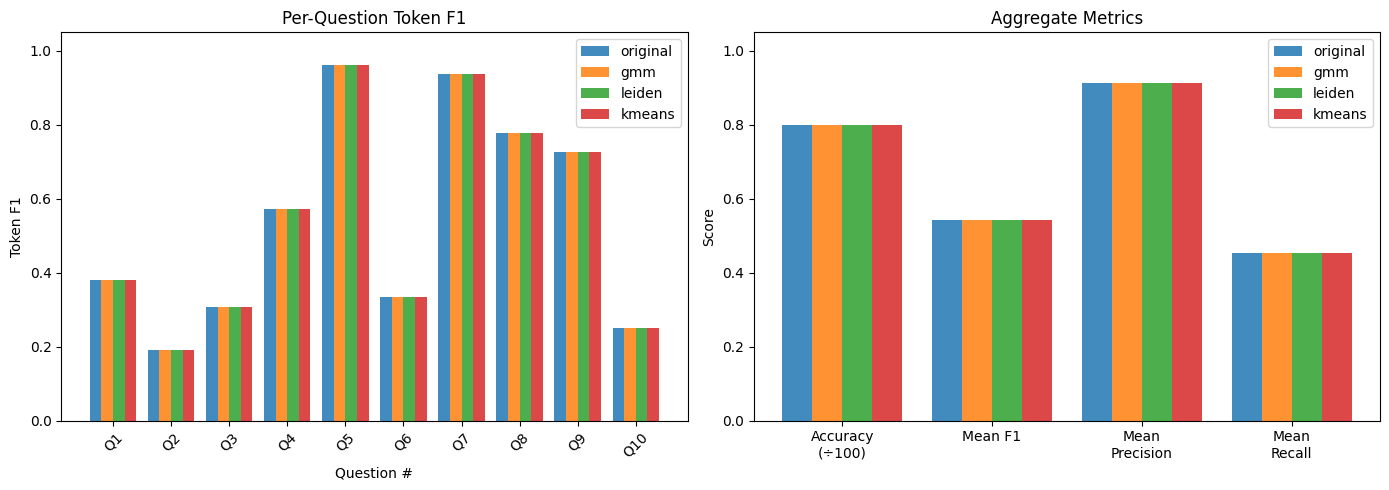

In [17]:
if len(df_detail) > 0:
    try:
        import matplotlib.pyplot as plt

        methods_present = [m for m in METHODS if m in df_detail["method"].unique()]
        n_methods = len(methods_present)
        n_questions = len(BENCHMARK)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # --- Left: per-question F1 grouped bar chart ---
        ax = axes[0]
        x = np.arange(n_questions)
        width = 0.8 / n_methods
        for i, method in enumerate(methods_present):
            f1_scores = df_detail[df_detail["method"] == method].sort_values("q_num")["f1"].values
            offset = (i - n_methods / 2 + 0.5) * width
            ax.bar(x + offset, f1_scores, width, label=method, alpha=0.85)
        ax.set_xlabel("Question #")
        ax.set_ylabel("Token F1")
        ax.set_title("Per-Question Token F1")
        ax.set_xticks(x)
        ax.set_xticklabels([f"Q{i+1}" for i in range(n_questions)], rotation=45)
        ax.legend()
        ax.set_ylim(0, 1.05)

        # --- Right: mean metrics bar chart ---
        ax2 = axes[1]
        metrics = ["accuracy_%", "mean_f1", "mean_precision", "mean_recall"]
        metric_labels = ["Accuracy\n(÷100)", "Mean F1", "Mean\nPrecision", "Mean\nRecall"]
        x2 = np.arange(len(metrics))
        width2 = 0.8 / n_methods
        for i, method in enumerate(methods_present):
            row = df_summary.loc[method]
            vals = [row["accuracy_%"] / 100, row["mean_f1"],
                    row["mean_precision"], row["mean_recall"]]
            offset = (i - n_methods / 2 + 0.5) * width2
            ax2.bar(x2 + offset, vals, width2, label=method, alpha=0.85)
        ax2.set_ylabel("Score")
        ax2.set_title("Aggregate Metrics")
        ax2.set_xticks(x2)
        ax2.set_xticklabels(metric_labels)
        ax2.legend()
        ax2.set_ylim(0, 1.05)

        plt.tight_layout()
        plt.show()
    except ImportError:
        print("(matplotlib not available — skipping charts)")

## 12. Export Results

Save both the summary and detail tables as CSVs for use in the thesis writeup.

In [18]:
if len(df_summary) > 0:
    df_summary.to_csv("results_summary.csv")
    print(f"Summary saved to results_summary.csv ({len(df_summary)} rows)")

if len(df_detail) > 0:
    df_detail.to_csv("results_detailed.csv", index=False)
    print(f"Details saved to results_detailed.csv ({len(df_detail)} rows)")

if len(df_tree) > 0:
    df_tree.to_csv("results_tree_stats.csv", index=False)
    print(f"Tree stats saved to results_tree_stats.csv ({len(df_tree)} rows)")

Summary saved to results_summary.csv (4 rows)
Details saved to results_detailed.csv (40 rows)
Tree stats saved to results_tree_stats.csv (4 rows)


---

# Part 2: Abstractive QA Evaluation on a Long Document

The Cinderella benchmark above is a short-document smoke test. This section runs the same three clustering methods on a longer document (~3600 words, ~48 chunks) where RAPTOR builds a real multi-layer tree. The QA pairs are abstractive (natural language answers, not extracted spans) so they match how generative models actually respond. Questions are categorized as local, cross-section, or global to measure whether hierarchical retrieval helps on multi-section synthesis.

## Model Tier

Set `MODEL_TIER` below to control which models are loaded for the long-document
evaluation. The tier table (further down) lists the options.

**Default is `"base"`** — this used to be flan-t5-base (broken: 512-token window
truncated top-5 retrieval, encoder-decoder forced through the causal-LM
pipeline). It is now Qwen2.5-1.5B-Instruct (32k window, decoder-only, ungated).
You should see clean output with no truncation warnings or
"T5ForConditionalGeneration is not supported" messages.


In [19]:
MODEL_TIER = "base"  # <-- change this to switch models

## Additional Metrics for Abstractive QA

ROUGE-L measures longest common subsequence, which is the standard metric for abstractive QA (Sarthi et al. used it on NarrativeQA). Contains-match gives credit when the correct answer is inside a verbose response. Retrieval hit rate measures whether the retrieved chunks contain the answer, independently of the generator.

In [20]:
def contains_match(prediction, ground_truth):
    gt_words = normalize_text(ground_truth).split()
    pred_norm = normalize_text(prediction)
    for i in range(len(gt_words) - 2):
        if " ".join(gt_words[i:i + 3]) in pred_norm:
            return True
    return False

def rouge_l(prediction, ground_truth):
    pt = normalize_text(prediction).split()
    gt = normalize_text(ground_truth).split()
    if not pt or not gt: return 0.0
    m, n = len(gt), len(pt)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if gt[i-1] == pt[j-1]: dp[i][j] = dp[i-1][j-1] + 1
            else: dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    lcs = dp[m][n]
    if lcs == 0: return 0.0
    p, r = lcs / n, lcs / m
    return 2 * p * r / (p + r)

def check_retrieval_hit(retrieved_text, answer):
    ret_lower = retrieved_text.lower()
    words = answer.lower().split()
    hits, checks = 0, 0
    for i in range(len(words) - 3):
        checks += 1
        if " ".join(words[i:i+4]) in ret_lower: hits += 1
    if checks == 0: return answer.lower() in ret_lower
    return (hits / checks) > 0.2

def score_prediction_v2(prediction, ground_truth):
    prec, rec, f1 = token_f1(prediction, ground_truth)
    cem = 1.0 if contains_match(prediction, ground_truth) else 0.0
    rl = rouge_l(prediction, ground_truth)
    return {"f1": f1, "precision": prec, "recall": rec, "contains_em": cem, "rouge_l": rl}

print("Abstractive metrics defined.")

Abstractive metrics defined.


## Load Long Document and Questions

The AI history document is ~3600 words (~48 RAPTOR chunks), long enough for a 3-layer tree. The 20 questions are split into local (single paragraph), cross (multi-section), and global (whole document) types.

In [21]:
import json as _json

with open("data/document.txt", "r") as f:
    LONG_DOCUMENT = f.read().strip()
with open("data/questions.json", "r") as f:
    LONG_BENCHMARK = _json.load(f)

print(f"Document: {len(LONG_DOCUMENT.split())} words, ~{len(LONG_DOCUMENT.split()) // 75} estimated chunks")
print(f"Questions: {len(LONG_BENCHMARK)} total")
print(f"  Types: {dict(Counter(q['type'] for q in LONG_BENCHMARK))}")

pd.DataFrame(LONG_BENCHMARK)[['type', 'question']].head(10)

Document: 1253 words, ~16 estimated chunks
Questions: 15 total
  Types: {'local': 5, 'cross': 5, 'global': 5}


,type,question
0,local,What was the Logic Theorist and who created it?
1,local,What caused the first AI winter?
2,local,Why did expert systems fail in the late 1980s?
3,local,What was the significance of AlexNet in 2012?
4,local,What is the Turing Test?
5,cross,How did neural network research evolve from th...
6,cross,Compare the two AI winters — what caused each ...
7,cross,How did government funding influence AI's prog...
8,cross,What role did games play in AI history?
9,cross,How did the approach to building AI systems sh...


## Model Wrappers (Tiered)

Wrappers around the QA and summarization models so the same `RetrievalAugmentation`
pipeline can swap between local HuggingFace models and API-based models without
changing downstream code.

**`LocalQAModel`** handles both encoder-decoder models (T5, BART) and decoder-only
models (Qwen, Llama, Mistral, Phi). It routes to the correct HF pipeline based on
the model's `is_encoder_decoder` config flag, and it explicitly truncates context
to fit the model's input window — both fixes for issues that previously caused
silent quality degradation in the `base` tier.

**`OpenAIQAModel`** and **`OpenAISummarizationModel`** wrap the OpenAI Chat
Completions API for the `api` and `api-gpt4` tiers. Requires `OPENAI_API_KEY`
in the environment.


In [22]:
class LocalQAModel(BaseQAModel):
    """
    Local HuggingFace QA model wrapper.

    Routes encoder-decoder models (T5, BART, Flan-T5) to the
    `text2text-generation` pipeline, and decoder-only models
    (Mistral, Llama, Qwen, Phi, GPT-2) to `text-generation`.

    Also performs explicit context truncation so the assembled prompt
    never silently exceeds the model's max input length.

    Default model: Qwen2.5-1.5B-Instruct (decoder-only, 32k context,
    ungated on HuggingFace, strong on small-model QA benchmarks).
    """

    def __init__(self, model_name="Qwen/Qwen2.5-1.5B-Instruct", max_new_tokens=128):
        self.model_name = model_name
        self.max_new_tokens = max_new_tokens
        self._pipeline = None
        self._tokenizer = None
        self._load_error = None
        self._is_causal = None
        self._max_input_tokens = None

    def _ensure_loaded(self):
        if self._pipeline is not None or self._load_error is not None:
            return
        try:
            from transformers import (
                pipeline as hf_pipeline,
                AutoConfig,
                AutoTokenizer,
            )

            config = AutoConfig.from_pretrained(self.model_name, trust_remote_code=True)

            # FIX #1: route encoder-decoder models to text2text-generation.
            # Previously both branches set task="text-generation", which forced
            # T5/BART through AutoModelForCausalLM and produced the
            # "T5ForConditionalGeneration is not supported" warning plus the
            # tied-weights warning.
            if hasattr(config, "is_encoder_decoder") and config.is_encoder_decoder:
                task = "text2text-generation"
                self._is_causal = False
            else:
                task = "text-generation"
                self._is_causal = True

            # FIX #2: cache the tokenizer so we can truncate context
            # deterministically before generation, instead of letting the
            # pipeline silently drop tokens past the model's window.
            self._tokenizer = AutoTokenizer.from_pretrained(
                self.model_name, trust_remote_code=True
            )

            # Discover the model's real input window. T5 = 512, BART = 1024,
            # Mistral = 32k, Qwen2.5 = 32k, Phi-3.5 = 128k.
            self._max_input_tokens = getattr(
                self._tokenizer, "model_max_length", 512
            )
            # HF sometimes reports 1_000_000_000 as a sentinel for "no limit".
            if self._max_input_tokens > 100_000:
                self._max_input_tokens = 4096 if self._is_causal else 512

            self._pipeline = hf_pipeline(
                task,
                model=self.model_name,
                tokenizer=self._tokenizer,
                trust_remote_code=True,
                device_map="auto",
            )
        except Exception as exc:
            self._load_error = exc
            print(f"QA model load failed: {exc}")

    def _build_prompt(self, context: str, question: str) -> str:
        """Assemble the prompt with context truncated to fit the window."""
        # FIX #3: explicitly truncate context to fit the encoder window.
        # Budget = max_input_tokens - prompt scaffold - question - reserved output.
        scaffold = (
            "Based on the following context, answer the question in one or "
            "two sentences. Be specific and include key names, dates, and "
            "facts from the context.\n\nContext: \n\nQuestion: \n\nAnswer:"
        )
        scaffold_tokens = len(self._tokenizer.encode(scaffold, add_special_tokens=False))
        question_tokens = len(self._tokenizer.encode(question, add_special_tokens=False))

        # For causal LMs the answer shares the window; for seq2seq it doesn't,
        # but we keep a buffer either way.
        reserved_for_output = self.max_new_tokens if self._is_causal else 16
        budget = self._max_input_tokens - scaffold_tokens - question_tokens - reserved_for_output
        budget = max(budget, 64)  # never go below 64 tokens of context

        ctx_ids = self._tokenizer.encode(context, add_special_tokens=False)
        if len(ctx_ids) > budget:
            ctx_ids = ctx_ids[:budget]
            context = self._tokenizer.decode(ctx_ids, skip_special_tokens=True)

        return (
            "Based on the following context, answer the question in one or "
            "two sentences. Be specific and include key names, dates, and "
            f"facts from the context.\n\nContext: {context}\n\n"
            f"Question: {question}\n\nAnswer:"
        )

    def answer_question(self, context, question):
        context = " ".join(str(context).split())
        question = str(question).strip()
        if not context:
            return ""

        self._ensure_loaded()
        if self._pipeline is None:
            return ""

        prompt = self._build_prompt(context, question)

        # FIX #4: pass only the generation kwargs valid for the selected mode.
        # do_sample=False makes temperature meaningless, so we omit it.
        gen_kwargs = {
            "max_new_tokens": self.max_new_tokens,
            "do_sample": False,
        }
        # FIX #5: suppress flan-t5's bundled max_length=20 default so we don't
        # get silently truncated answers if a caller forgets max_new_tokens.
        if not self._is_causal:
            gen_kwargs["max_length"] = None

        try:
            result = self._pipeline(prompt, **gen_kwargs)
            if self._is_causal:
                full = result[0]["generated_text"]
                # text-generation returns prompt+continuation; split on "Answer:".
                if "Answer:" in full:
                    return full.split("Answer:")[-1].strip()
                return full[len(prompt):].strip()
            # text2text-generation returns only the generated text.
            return result[0]["generated_text"].strip()
        except Exception as exc:
            print(f"QA generation error: {exc}")
            return ""


class OpenAIQAModel(BaseQAModel):
    def __init__(self, model_name="gpt-4o-mini", max_tokens=150):
        self.model_name = model_name
        self.max_tokens = max_tokens
        self._client = None
    def _ensure_client(self):
        if self._client is not None: return
        from openai import OpenAI
        self._client = OpenAI()
    def answer_question(self, context, question):
        context = " ".join(str(context).split())
        if not context: return ""
        self._ensure_client()
        try:
            r = self._client.chat.completions.create(model=self.model_name, messages=[{"role":"system","content":"You are a precise QA assistant. Answer based only on the provided context in one or two sentences. Include key names, dates, and facts."},{"role":"user","content":f"Context: {context}\n\nQuestion: {question}"}], max_tokens=self.max_tokens, temperature=0)
            return r.choices[0].message.content.strip()
        except Exception as exc:
            print(f"OpenAI error: {exc}")
            return ""

class OpenAISummarizationModel(BaseSummarizationModel):
    def __init__(self, model_name="gpt-4o-mini", max_tokens=150):
        self.model_name = model_name
        self.max_tokens = max_tokens
        self._client = None
    def _ensure_client(self):
        if self._client is not None: return
        from openai import OpenAI
        self._client = OpenAI()
    def summarize(self, context, max_tokens=150):
        text = " ".join(str(context).split())
        if not text: return ""
        self._ensure_client()
        try:
            r = self._client.chat.completions.create(model=self.model_name, messages=[{"role":"system","content":"Summarize concisely, preserving key facts, names, and dates."},{"role":"user","content":text}], max_tokens=self.max_tokens, temperature=0)
            return r.choices[0].message.content.strip()
        except Exception:
            return text[:200]

print("Tiered model wrappers defined.")

Tiered model wrappers defined.


## Load Models for Selected Tier

The `TIERS` dictionary defines four reproducibility levels for the benchmark:

| Tier          | QA model                       | Context | Purpose                                                              |
|---------------|--------------------------------|---------|----------------------------------------------------------------------|
| `base`        | Qwen2.5-1.5B-Instruct          | 32k     | Small-model floor — can a tiny generator distinguish clustering quality? |
| `local-large` | Qwen2.5-3B-Instruct            | 32k     | Mid-small generator                                                  |
| `local-xl`    | Qwen2.5-7B-Instruct            | 32k     | Mid-sized open generator, same size class as Mistral                 |
| `mistral`     | Mistral-7B-Instruct-v0.3       | 32k     | Reviewer-familiar baseline                                           |
| `api`         | gpt-4o-mini                    | 128k    | Strong proprietary baseline                                          |
| `api-gpt4`    | gpt-4o                         | 128k    | Ceiling — does the gap between clustering methods collapse here?     |

If the gap between clustering methods *shrinks* as you climb tiers, that suggests
retrieval structure matters less when the generator is stronger — directly
addressing the "RAG vs Long Context" open question in Gao et al. 2024 (§VII-A).
If the gap *persists*, hierarchical retrieval is providing something the
generator cannot recover on its own. Either result is informative.


In [23]:
# Tier definitions. Each tier specifies an embedding model, a summarizer,
# and a QA model. The "type" tag ("local" vs "api") tells the wrapper which
# class to instantiate.
#
# CHANGED: base tier now uses Qwen2.5-1.5B-Instruct instead of flan-t5-base.
#   Rationale:
#     - flan-t5-base has a 512-token input window, which silently truncates
#       top-5 retrieved chunks. That made base-tier comparisons between
#       clustering methods uninterpretable (an evaluation confound, not a
#       fair test of GMM vs Leiden).
#     - Qwen2.5-1.5B-Instruct has a 32k window, is decoder-only (cleaner
#       routing), ungated on HuggingFace, and is competitive with or
#       stronger than flan-t5-large on small-model QA benchmarks per the
#       Qwen2.5 technical report (Yang et al. 2024, arXiv:2412.15115).
#     - Fits comfortably on a free Colab T4 GPU (~3GB in fp16).

TIERS = {
    "base":        {"emb": "sentence-transformers/all-MiniLM-L6-v2",          "summ": ("local", "sshleifer/distilbart-cnn-12-6"), "qa": ("local", "Qwen/Qwen2.5-1.5B-Instruct")},
    "local-large": {"emb": "sentence-transformers/multi-qa-mpnet-base-cos-v1", "summ": ("local", "facebook/bart-large-cnn"),       "qa": ("local", "Qwen/Qwen2.5-3B-Instruct")},
    "local-xl":    {"emb": "sentence-transformers/multi-qa-mpnet-base-cos-v1", "summ": ("local", "facebook/bart-large-cnn"),       "qa": ("local", "Qwen/Qwen2.5-7B-Instruct")},
    "mistral":     {"emb": "sentence-transformers/multi-qa-mpnet-base-cos-v1", "summ": ("local", "facebook/bart-large-cnn"),       "qa": ("local", "mistralai/Mistral-7B-Instruct-v0.3")},
    "api":         {"emb": "sentence-transformers/multi-qa-mpnet-base-cos-v1", "summ": ("api",   "gpt-4o-mini"),                  "qa": ("api",   "gpt-4o-mini")},
    "api-gpt4":    {"emb": "sentence-transformers/multi-qa-mpnet-base-cos-v1", "summ": ("api",   "gpt-4o"),                       "qa": ("api",   "gpt-4o")},
}

tier = TIERS[MODEL_TIER]
print(f"Loading tier: {MODEL_TIER}")

emb2 = SBertEmbeddingModel(model_name=tier["emb"])
st, sn = tier["summ"]
summ2 = OpenAISummarizationModel(model_name=sn) if st == "api" else LocalBartSummarizationModel(model_name=sn)
qt, qn = tier["qa"]
qa2 = OpenAIQAModel(model_name=qn) if qt == "api" else LocalQAModel(model_name=qn)

print(f"  Embeddings: {tier['emb']}")
print(f"  Summarizer: {sn} ({st})")
print(f"  QA model:   {qn} ({qt})")
print("Models ready.")


Loading tier: base


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Embeddings: sentence-transformers/all-MiniLM-L6-v2
  Summarizer: sshleifer/distilbart-cnn-12-6 (local)
  QA model:   Qwen/Qwen2.5-1.5B-Instruct (local)
Models ready.


## Config Factories (Long Document)

Same three clustering methods as Part 1, now using the tiered models.

In [24]:
def make_original_config_v2():
    return RetrievalAugmentationConfig(
        embedding_model=emb2, summarization_model=summ2, qa_model=qa2,
        tb_max_tokens=100, tb_num_layers=3, tb_summarization_length=100,
        tr_top_k=5, tr_selection_mode="top_k")

def make_gmm_config_v2():
    clusterer = GMMClusterer(reduction_dimension=10, soft_threshold=0.1, force_hard_clustering=False, random_state=224)
    tc = ClusterTreeConfig(
        clustering_algorithm=clusterer, clustering_params={}, reduction_dimension=10,
        summarization_model=summ2, embedding_models={"EMB": emb2},
        cluster_embedding_model="EMB", max_tokens=100, num_layers=3, summarization_length=100)
    return RetrievalAugmentationConfig(
        tree_builder_config=tc, qa_model=qa2, embedding_model=emb2,
        tr_top_k=5, tr_selection_mode="top_k")

def make_leiden_config_v2():
    lcfg = LeidenConfig(k_neighbors=10, use_adjacency_edges=True, adjacency_weight=0.5,
        resolution=1.0, resolution_schedule={0: 1.2, 1: 0.8},
        partition_type="RBConfiguration", min_cluster_size=1)
    clusterer = LeidenClusterer(config=lcfg, random_state=224)
    tc = ClusterTreeConfig(
        clustering_algorithm=clusterer, clustering_params={}, reduction_dimension=10,
        summarization_model=summ2, embedding_models={"EMB": emb2},
        cluster_embedding_model="EMB", max_tokens=100, num_layers=3, summarization_length=100)
    return RetrievalAugmentationConfig(
        tree_builder_config=tc, qa_model=qa2, embedding_model=emb2,
        tr_top_k=5, tr_selection_mode="top_k")

def make_kmeans_config_v2():
    clusterer = KMeansClusterer(k_strategy="silhouette", max_k=10, random_state=224)
    tc = ClusterTreeConfig(
        clustering_algorithm=clusterer, clustering_params={}, reduction_dimension=10,
        summarization_model=summ2, embedding_models={"EMB": emb2},
        cluster_embedding_model="EMB", max_tokens=100, num_layers=3, summarization_length=100)
    return RetrievalAugmentationConfig(
        tree_builder_config=tc, qa_model=qa2, embedding_model=emb2,
        tr_top_k=5, tr_selection_mode="top_k")


METHODS_V2 = {
    "original": (make_original_config_v2, "RAPTOR GMM+UMAP upstream"),
    "gmm":      (make_gmm_config_v2,      "GMMClusterer new interface"),
    "leiden":   (make_leiden_config_v2,     "LeidenClusterer k-NN graph"),
     "kmeans":  (make_kmeans_config_v2, "KMeansClusterer (silhouette K)"),
}
print(f"Registered {len(METHODS_V2)} methods for long document evaluation.")

Registered 4 methods for long document evaluation.


## Run Long Document Evaluation

For each method: build tree, answer all 20 questions, compute Token F1, ROUGE-L, contains-match, and retrieval hit rate. Retrieval hit rate is the metric that isolates clustering quality from generation quality.

In [25]:
long_summary_rows = []
long_detail_rows = []
long_tree_rows = []

for method_name, (factory_fn, description) in METHODS_V2.items():
    print(f"\n{'='*60}")
    print(f"  {method_name} — {description}")
    print(f"{'='*60}")

    try:
        config = factory_fn()
    except ImportError as exc:
        print(f"  SKIPPED: {exc}")
        continue

    ra = RetrievalAugmentation(config=config)
    t0 = time.time()
    ra.add_documents(LONG_DOCUMENT)
    build_time = time.time() - t0

    tree = ra.tree
    total_nodes = len(tree.all_nodes)
    leaf_nodes = len(tree.leaf_nodes)
    summary_nodes = total_nodes - leaf_nodes
    print(f"  Tree: {tree.num_layers} layers, {total_nodes} nodes ({leaf_nodes} leaves + {summary_nodes} summaries) in {build_time:.1f}s")

    for li, nodes in sorted(tree.layer_to_nodes.items()):
        long_tree_rows.append({"method": method_name, "layer": li, "nodes": len(nodes)})

    totals = {"f1": 0, "rouge_l": 0, "contains_em": 0, "ret_hit": 0}
    type_totals = {}

    for i, qa_pair in enumerate(LONG_BENCHMARK):
        predicted = ra.answer_question(question=qa_pair["question"])
        scores = score_prediction_v2(predicted, qa_pair["answer"])

        try:
            retrieved = ra.retrieve(qa_pair["question"])
            hit = check_retrieval_hit(retrieved, qa_pair["answer"])
        except Exception:
            retrieved, hit = "", False

        scores["retrieval_hit"] = int(hit)
        for k in totals: totals[k] += scores.get(k, 0)

        qtype = qa_pair["type"]
        if qtype not in type_totals:
            type_totals[qtype] = {"f1": 0, "rouge_l": 0, "ret_hit": 0, "n": 0}
        type_totals[qtype]["f1"] += scores["f1"]
        type_totals[qtype]["rouge_l"] += scores["rouge_l"]
        type_totals[qtype]["ret_hit"] += scores["retrieval_hit"]
        type_totals[qtype]["n"] += 1

        long_detail_rows.append({
            "method": method_name, "q_num": i+1, "type": qtype,
            "question": qa_pair["question"], "ground_truth": qa_pair["answer"],
            "predicted": predicted,
            "f1": round(scores["f1"], 4), "rouge_l": round(scores["rouge_l"], 4),
            "contains_em": int(scores["contains_em"]), "retrieval_hit": int(hit),
        })

    n = len(LONG_BENCHMARK)
    long_summary_rows.append({
        "method": method_name, "description": description, "model_tier": MODEL_TIER,
        "mean_f1": round(totals["f1"]/n, 4), "mean_rouge_l": round(totals["rouge_l"]/n, 4),
        "contains_em_%": round(totals["contains_em"]/n*100, 1),
        "retrieval_hit_%": round(totals["ret_hit"]/n*100, 1),
        "layers": tree.num_layers, "total_nodes": total_nodes,
        "leaves": leaf_nodes, "summaries": summary_nodes,
        "build_sec": round(build_time, 2),
    })
    print(f"  F1={totals['f1']/n:.4f}  ROUGE-L={totals['rouge_l']/n:.4f}  RetHit={totals['ret_hit']/n*100:.0f}%")

print("\nAll methods complete.")


  original — RAPTOR GMM+UMAP upstream


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

  F1=0.3987  ROUGE-L=0.3024  RetHit=0%

  kmeans — KMeansClusterer (silhouette K)


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Tree: 1 layers, 25 nodes (18 leaves + 7 summaries) in 9.5s


Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=128) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

  F1=0.3662  ROUGE-L=0.2792  RetHit=0%

All methods complete.


## Long Document: Summary Table

Same format as Part 1 but with ROUGE-L and retrieval hit rate added. Retrieval hit rate is the most important column for comparing clustering methods since it does not depend on the generator.

In [26]:
df_long_summary = pd.DataFrame(long_summary_rows).set_index("method")

higher = ["mean_f1", "mean_rouge_l", "contains_em_%", "retrieval_hit_%"]
lower = ["build_sec"]
def hl(col):
    styles = [""] * len(col)
    if col.name in higher: best = col.idxmax()
    elif col.name in lower: best = col.idxmin()
    else: return styles
    for i, idx in enumerate(col.index):
        if idx == best: styles[i] = "background-color: #d4edda; font-weight: bold"
    return styles

df_long_summary.style.apply(hl).format({
    "mean_f1": "{:.4f}", "mean_rouge_l": "{:.4f}",
    "contains_em_%": "{:.1f}%", "retrieval_hit_%": "{:.1f}%", "build_sec": "{:.2f}s",
}).set_caption("Long Document: Clustering Method Comparison")

,description,model_tier,mean_f1,mean_rouge_l,contains_em_%,retrieval_hit_%,layers,total_nodes,leaves,summaries,build_sec
method,,,,,,,,,,,
original,RAPTOR GMM+UMAP upstream,base,0.3639,0.2719,73.3%,0.0%,1,21,18,3,14.89s
gmm,GMMClusterer new interface,base,0.4131,0.2950,66.7%,0.0%,1,21,18,3,5.56s
leiden,LeidenClusterer k-NN graph,base,0.3987,0.3024,73.3%,0.0%,1,21,18,3,4.83s
kmeans,KMeansClusterer (silhouette K),base,0.3662,0.2792,73.3%,0.0%,1,25,18,7,9.48s


## Long Document: Results by Question Type

If a clustering method improves on cross-section questions but not local ones, that suggests the improvement comes from better summary nodes rather than better leaf-level retrieval.

In [27]:
df_long_detail = pd.DataFrame(long_detail_rows)
if len(df_long_detail) > 0:
    by_type = df_long_detail.groupby(["method", "type"]).agg(
        n=("f1", "count"), mean_f1=("f1", "mean"),
        mean_rouge_l=("rouge_l", "mean"), ret_hit=("retrieval_hit", "mean"),
    ).round(4)
    by_type["ret_hit"] = (by_type["ret_hit"] * 100).round(1)
    by_type.columns = ["n", "mean_f1", "mean_rouge_l", "ret_hit_%"]
    display(by_type.style.set_caption("Results by Question Type"))

## Long Document: Tree Structure

With ~48 chunks the tree should have 3 layers. Differences in node counts per layer directly reflect the clustering algorithm.

method,gmm,kmeans,leiden,original
layer,,,,
0,18,18,18,18
1,3,7,3,3
TOTAL,21,25,21,21


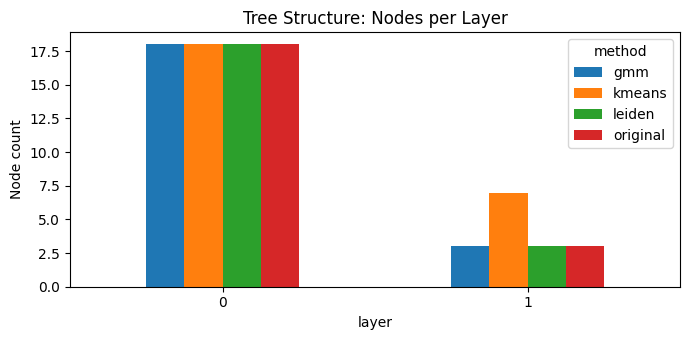

In [28]:
df_long_tree = pd.DataFrame(long_tree_rows)
if len(df_long_tree) > 0:
    pt = df_long_tree.pivot(index="layer", columns="method", values="nodes").fillna(0).astype(int)
    pt.loc["TOTAL"] = pt.sum()
    display(pt.style.set_caption("Nodes per Tree Layer"))

    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(7, 3.5))
        pt.drop("TOTAL").plot(kind="bar", ax=ax)
        ax.set_ylabel("Node count")
        ax.set_title("Tree Structure: Nodes per Layer")
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except ImportError:
        print("matplotlib not available")

## Export Long Document Results

In [29]:
df_long_summary.to_csv("results_long_summary.csv")
df_long_detail.to_csv("results_long_detailed.csv", index=False)
df_long_tree.to_csv("results_long_tree.csv", index=False)
print("Saved: results_long_summary.csv, results_long_detailed.csv, results_long_tree.csv")

Saved: results_long_summary.csv, results_long_detailed.csv, results_long_tree.csv
